In [2]:
#Simple Linear Regression
#===================================
#Import Required Libraries

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical modeling
import statsmodels.api as sm

# Statistical tests
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [4]:
#Load the Dataset
#=============================

# Load dataset
df = pd.read_csv('C:/Users/HP/Downloads/market_sales.csv')

# Display first 5 rows
print(df.head())

     TV      Radio  Social_Media       Sales
0  16.0   6.566231      2.907983   54.732757
1  13.0   9.237765      2.409567   46.677897
2  41.0  15.886446      2.913410  150.177829
3  83.0  30.020028      6.922304  298.246340
4  15.0   8.437408      1.405998   56.594181


In [6]:
#Explore the Dataset
#----------------------------------
## Check dataset shape
print("Dataset Shape:")
print(df.shape)

# Display column names
print("\nColumns:")
print(df.columns)

# Dataset information
print("\nDataset Info:")
print(df.info())

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

Dataset Shape:
(4572, 4)

Columns:
Index(['TV', 'Radio', 'Social_Media', 'Sales'], dtype='str')

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB
None

Statistical Summary:
                TV        Radio  Social_Media        Sales
count  4562.000000  4568.000000   4566.000000  4566.000000
mean     54.066857    18.160356      3.323956   192.466602
std      26.125054     9.676958      2.212670    93.133092
min      10.000000     0.000684      0.000031    31.199409
25%      32.000000    10.525957      1.527849   112.322882
50%      53.000000    17.859513      3.055565   189.231172
75%      77.000000    25.649730      4.807558   272.50

In [8]:
## Check missing values
print(df.isnull().sum())

#Handle Missing Values
## Remove missing values
df = df.dropna()

# Confirm missing values removed
print(df.isnull().sum())

TV              0
Radio           0
Social_Media    0
Sales           0
dtype: int64
TV              0
Radio           0
Social_Media    0
Sales           0
dtype: int64


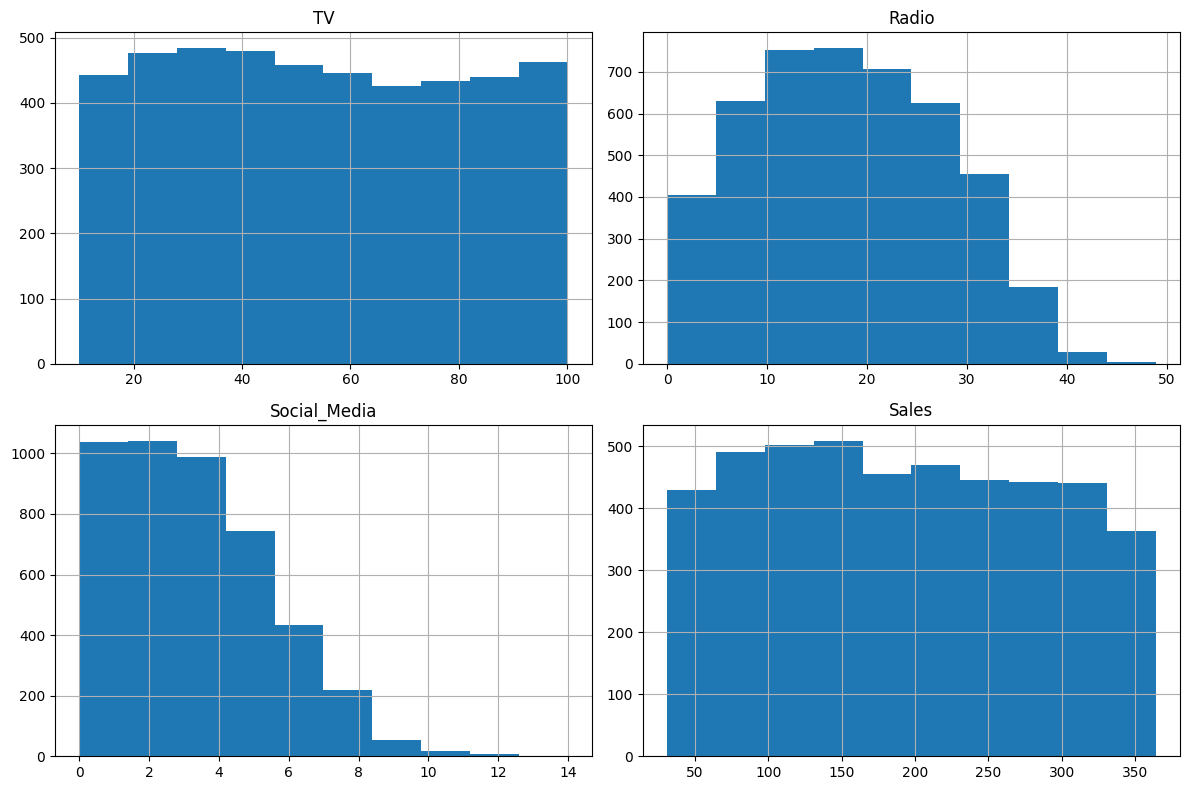

In [10]:
#Exploratory Data Analysis (EDA)

## Plot histograms
df.hist(figsize=(12,8))

plt.tight_layout()
plt.show()

                    TV     Radio  Social_Media     Sales
TV            1.000000  0.869158      0.527687  0.999497
Radio         0.869158  1.000000      0.606338  0.868638
Social_Media  0.527687  0.606338      1.000000  0.527446
Sales         0.999497  0.868638      0.527446  1.000000


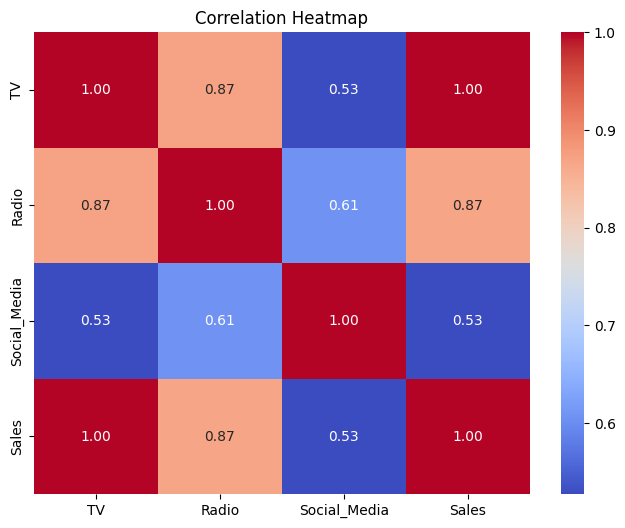

In [12]:
#Correlation Analysis
# Correlation matrix
corr_matrix = df.corr()

# Display correlation matrix
print(corr_matrix)

#Correlation Heatmap

# Plot heatmap
plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Heatmap')

plt.show()

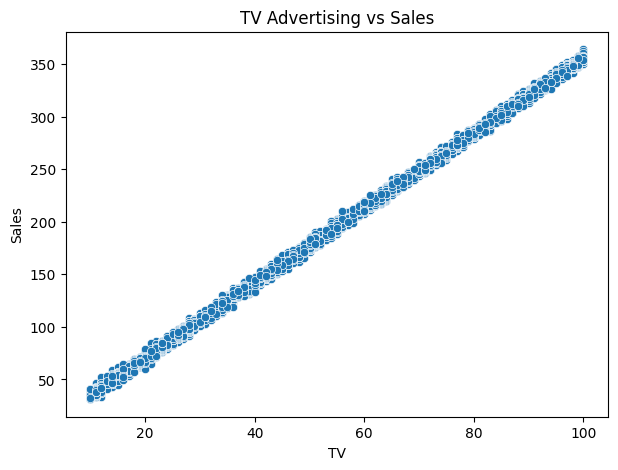

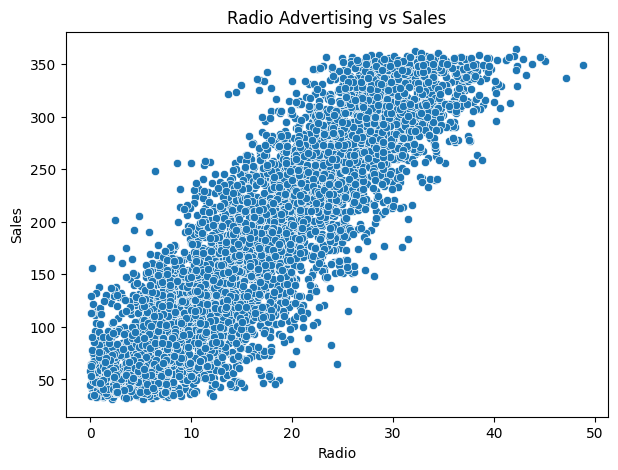

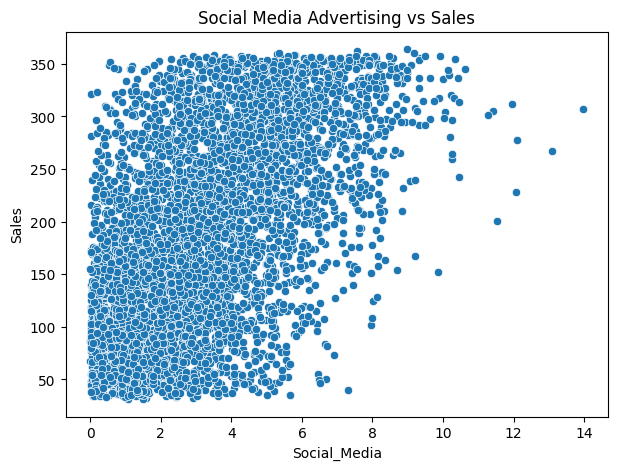

In [14]:
#Scatterplots Against Sales

#TV vs Sales

plt.figure(figsize=(7,5))

sns.scatterplot(x='TV',
                y='Sales',
                data=df)

plt.title('TV Advertising vs Sales')

plt.show()

#Radio vs Sales

plt.figure(figsize=(7,5))

sns.scatterplot(x='Radio',
                y='Sales',
                data=df)

plt.title('Radio Advertising vs Sales')

plt.show()

#Social Media vs Sales

plt.figure(figsize=(7,5))

sns.scatterplot(x='Social_Media',
                y='Sales',
                data=df)

plt.title('Social Media Advertising vs Sales')

plt.show()

In [16]:
#Determine Most Correlated Variable with Sales
#===============================================

## Correlation with Sales
sales_corr = corr_matrix['Sales'].sort_values(ascending=False)

print(sales_corr)

#Select Independent Variable

# Independent variable
X = df[['TV']]

# Dependent variable
y = df['Sales']

#Add Constant (Intercept)
## Add constant
X = sm.add_constant(X)

print(X.head())

Sales           1.000000
TV              0.999497
Radio           0.868638
Social_Media    0.527446
Name: Sales, dtype: float64
   const    TV
0    1.0  16.0
1    1.0  13.0
2    1.0  41.0
3    1.0  83.0
4    1.0  15.0


In [18]:
#Build Simple Linear Regression Model
#======================================

## Fit OLS regression model
model = sm.OLS(y, X).fit()

# Display model summary
print(model.summary())

#Extract Important Regression Outputs
#============================================

#R-squared

print("R-squared:")
print(model.rsquared)

#Coefficients

print("Model Coefficients:")
print(model.params)

#P-values

print("P-values:")
print(model.pvalues)

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Fri, 29 May 2026   Prob (F-statistic):               0.00
Time:                        19:14:39   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

In [20]:
#Make Predictions
#======================================

# Predict sales
predictions = model.predict(X)

# Display first predictions
print(predictions.head())

0     56.851733
1     46.167191
2    145.889585
3    295.473177
4     53.290219
dtype: float64


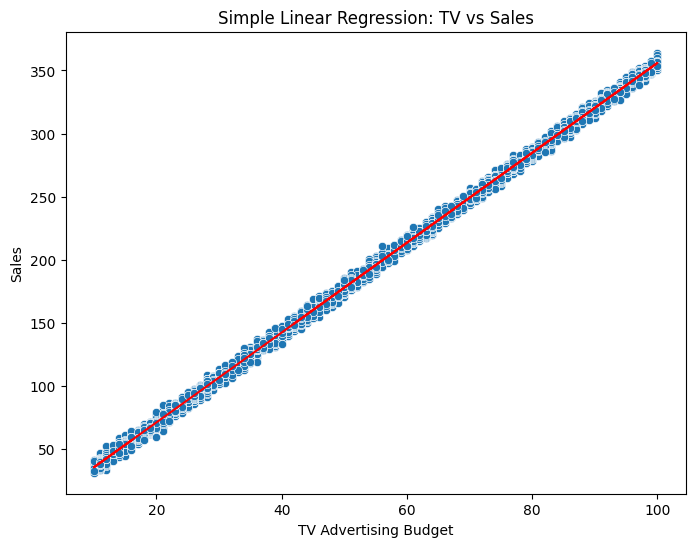

In [22]:
#Plot Regression Line
#========================================

plt.figure(figsize=(8,6))

# Scatterplot
sns.scatterplot(x=df['TV'],
                y=df['Sales'])

# Regression line
plt.plot(df['TV'],
         predictions,
         color='red')

plt.xlabel('TV Advertising Budget')
plt.ylabel('Sales')
plt.title('Simple Linear Regression: TV vs Sales')

plt.show()

In [24]:
#Residual Analysis
#==================================

# Residuals
residuals = y - predictions

# Display first residuals
print(residuals.head())

0   -2.118976
1    0.510706
2    4.288243
3    2.773162
4    3.303962
dtype: float64


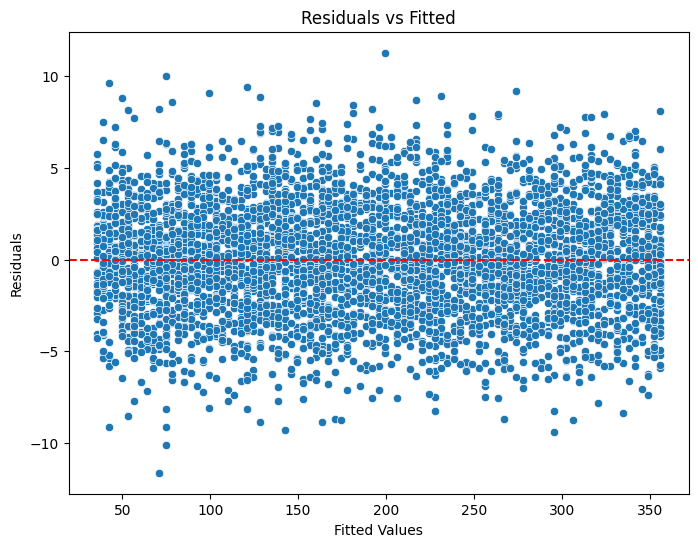

In [26]:
#Diagnostic Plot — Residuals vs Fitted Values
#------------------------------------------------
#-------------------------------------------------
#Checking Linearity & Homoscedasticity

plt.figure(figsize=(8,6))

sns.scatterplot(x=predictions,
                y=residuals)

plt.axhline(y=0,
            color='red',
            linestyle='--')

plt.xlabel('Fitted Values')
plt.ylabel('Residuals')

plt.title('Residuals vs Fitted')

plt.show()

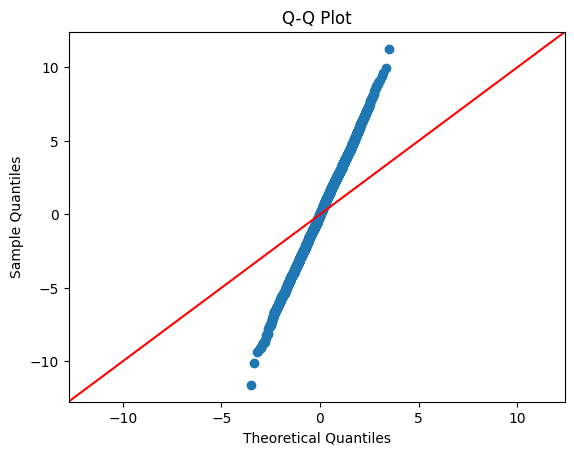

In [28]:
#Q-Q Plot for Normality
#==============================

sm.qqplot(residuals,
          line='45')

plt.title('Q-Q Plot')

plt.show()

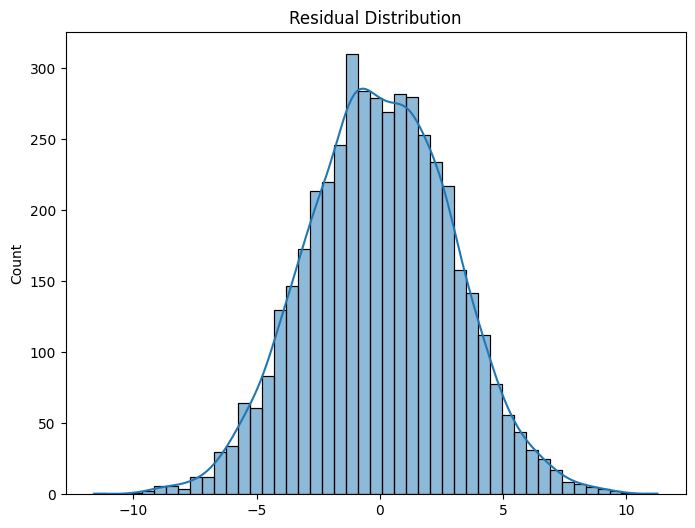

{'LM Statistic': np.float64(5.926876708239881e-05), 'LM-Test p-value': np.float64(0.9938574497493051), 'F-Statistic': np.float64(5.924269295488131e-05), 'F-Test p-value': np.float64(0.9938591388964036)}


In [30]:
#Histogram of Residuals
#==============================

plt.figure(figsize=(8,6))

sns.histplot(residuals,
             kde=True)

plt.title('Residual Distribution')

plt.show()

#Checking Homoscedasticity
#==================================

# Breusch-Pagan test
bp_test = het_breuschpagan(residuals, X)

# Labels
labels = ['LM Statistic',
          'LM-Test p-value',
          'F-Statistic',
          'F-Test p-value']

# Display results
print(dict(zip(labels, bp_test)))

In [32]:
#Business Interpretation
#==========================================

#R-Squared Interpretation

print(f"""
R-squared Interpretation:

The model explains {round(model.rsquared * 100, 2)}%
of the variation in Sales using TV advertising budget.
""")

#Coefficient Interpretation

tv_coef = model.params['TV']

print(f"""
Coefficient Interpretation:

For every additional 1-unit increase in TV advertising,
Sales increase by approximately {round(tv_coef, 2)} units.
""")

#P-value Interpretation

tv_pvalue = model.pvalues['TV']

print(f"""
P-value Interpretation:

The p-value for TV advertising is {tv_pvalue}.

Since the p-value is less than 0.05,
TV advertising is statistically significant.
""")


R-squared Interpretation:

The model explains 99.9%
of the variation in Sales using TV advertising budget.


Coefficient Interpretation:

For every additional 1-unit increase in TV advertising,
Sales increase by approximately 3.56 units.


P-value Interpretation:

The p-value for TV advertising is 0.0.

Since the p-value is less than 0.05,
TV advertising is statistically significant.



In [34]:
#ROI-Based Recommendation
#========================================

print("""
Business Recommendation:

TV advertising has the strongest relationship with Sales
and is statistically significant.

The company should allocate more marketing budget toward
TV campaigns because increases in TV spending lead to
higher predicted sales.

This indicates that TV advertising provides the strongest
Return on Investment (ROI) among the available marketing channels.
""")


Business Recommendation:

TV advertising has the strongest relationship with Sales
and is statistically significant.

The company should allocate more marketing budget toward
TV campaigns because increases in TV spending lead to
higher predicted sales.

This indicates that TV advertising provides the strongest
Return on Investment (ROI) among the available marketing channels.

